# Notebook 04 (Revised) — Synthetic Data Augmentation

**CMSC 190 Special Problem**
*Classification of High-Protein and Low-Protein Corn (Zea Mays) Using NIR Spectral Data and Machine Learning Techniques*

---

This notebook implements a **revised augmentation strategy** that is methodologically distinct from the original `04_augmentation.ipynb`.

| Notebook | Strategy |
|---|---|
| `04_augmentation.ipynb` (original) | 80 / 20 train-test split → 64 train, 16 test, then augment train set |
| **`04_augmentation_revised.ipynb` (this notebook)** | **All 80 originals → test set; train exclusively on 1936 synthetic samples** |

**Key motivation:** with only 80 original samples, a standard 80 / 20 split produces a test set of just 16 samples, making accuracy estimates highly sensitive to a single mis-classification (each error = 6.25 % accuracy swing). Reserving all 80 originals as the test set yields more statistically reliable metrics.

**Output files (saved to `data/processed/revised/`):**
- `X_train_synthetic.npy` — 1936 synthetic training samples
- `y_train_synthetic.npy` — labels for synthetic samples
- `X_test_all.npy` — all 80 original samples (test set)
- `y_test_all.npy` — all 80 original labels
- `combined_augmented_revised.csv` — synthetic training set as CSV (documentation)


note: this does not import functions from augmentor.py. All logic is inside this notebook

## Section 1 — Imports and Setup

This cell imports all the libraries needed for this notebook and configures global settings.

- **`numpy`** handles all array operations and random number generation
- **`pandas`** is used to save the synthetic dataset as a CSV file for documentation
- **`matplotlib` / `seaborn`** are used for all visualizations
- **`os`** is used to create output directories

All random operations use `random_state = 42` and `np.random.seed(42)` so that every run of this notebook produces identical results.

In [22]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- Reproducibility ---
random_state = 42
np.random.seed(42)

# --- Plot style ---
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# --- Create output directory for revised files ---
os.makedirs('../../data/processed/revised', exist_ok=True)

print("Imports complete.")
print(f"Output directory ready: ../../data/processed/revised/")

Imports complete.
Output directory ready: ../../data/processed/revised/


## Section 2 — Load Preprocessed Data

Here we load the three arrays produced by Notebook 03 (Savitzky-Golay preprocessing):

- **`X_preprocessed.npy`** — the smoothed NIR spectra, shape (80, 700)
- **`y_labels.npy`** — binary protein labels: 0 = Low Protein, 1 = High Protein
- **`sample_ids.npy`** — original sample identifiers from the raw dataset

> **Revised approach:** In this notebook, ALL 80 original samples are reserved exclusively for the test set. None of the original spectra will appear in the training data. This is the fundamental difference from the original `04_augmentation.ipynb`.

In [23]:
# Load the preprocessed NIR spectra and labels.
# Paths are relative to the notebooks/revised/ directory.
X          = np.load('../../data/processed/X_preprocessed.npy')
y          = np.load('../../data/processed/y_labels.npy')
sample_ids = np.load('../../data/processed/sample_ids.npy', allow_pickle=True)

print("=== Loaded Array Shapes ===")
print(f"X          : {X.shape}   (samples × wavelength points)")
print(f"y          : {y.shape}")
print(f"sample_ids : {sample_ids.shape}")

print("\n=== Class Distribution ===")
classes, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(classes, counts):
    label = 'High Protein' if cls == 1 else 'Low Protein'
    print(f"  Class {int(cls)} ({label}): {cnt} samples ({cnt / len(y) * 100:.1f} %)")

=== Loaded Array Shapes ===
X          : (80, 700)   (samples × wavelength points)
y          : (80,)
sample_ids : (80,)

=== Class Distribution ===
  Class 0 (Low Protein): 40 samples (50.0 %)
  Class 1 (High Protein): 40 samples (50.0 %)


## Section 3 — Reserve All 80 Original Samples as Test Set

In the original `04_augmentation.ipynb`, 20 % of the dataset (16 samples) was held out as the test set. This notebook takes a different approach: **all 80 original samples become the test set**.

**Why is this methodologically justified?**

1. **Statistical reliability** — a 16-sample test set means that a single mis-classification shifts accuracy by 6.25 percentage points. An 80-sample test set reduces this granularity to 1.25 percentage points, which provides much more stable and trustworthy evaluation metrics.

2. **No information leakage** — the model will be trained exclusively on *synthetic* samples generated by linear interpolation. Because these synthetic samples are mathematically derived (not real recordings), the model is never exposed to any actual spectrum during training.

3. **Defensibility** — interpolated samples lie strictly *between* two original points in feature space (alpha ∈ (0.1, 0.9)), ensuring they are physically plausible spectra but numerically distinct from all 80 originals.

4. **Precedent** — this strategy mirrors the approach used in the SpecTran study (Li et al., 2025), which generated a purely synthetic training set and evaluated on the original collected spectra.

This is noted as a deliberate methodological improvement over the original pipeline.

In [24]:
# All 80 original samples are assigned directly to the test set.
# No train/test split is performed — that is the key change in this revision.
X_test_all = X
y_test_all = y

print("=== Test Set (all original samples) ===")
print(f"X_test_all : {X_test_all.shape}")
print(f"y_test_all : {y_test_all.shape}")

print("\n=== Class Distribution (test set) ===")
classes_t, counts_t = np.unique(y_test_all, return_counts=True)
for cls, cnt in zip(classes_t, counts_t):
    label = 'High Protein' if cls == 1 else 'Low Protein'
    print(f"  Class {int(cls)} ({label}): {cnt} samples ({cnt / len(y_test_all) * 100:.1f} %)")

=== Test Set (all original samples) ===
X_test_all : (80, 700)
y_test_all : (80,)

=== Class Distribution (test set) ===
  Class 0 (Low Protein): 40 samples (50.0 %)
  Class 1 (High Protein): 40 samples (50.0 %)


## Section 4 — Generate Synthetic Training Samples

This section creates the training set entirely from **synthetic spectra** using **linear interpolation** (convex combination) of pairs of original samples.

**How interpolation works:**
For each synthetic sample:
1. Two distinct original spectra are chosen at random: `X[idx1]` and `X[idx2]`
2. A mixing coefficient `alpha` is sampled uniformly from the range **(0.1, 0.9)**
3. The synthetic spectrum is computed as: `x_new = alpha × X[idx1] + (1 − alpha) × X[idx2]`
4. The label is interpolated the same way and rounded to the nearest integer: `y_new = round(alpha × y[idx1] + (1 − alpha) × y[idx2])`

**Why alpha ∈ (0.1, 0.9)?**
Restricting alpha away from the extremes (0 and 1) ensures every synthetic sample is a genuine mixture — never identical to either parent spectrum. This maintains the mathematical distinctness between the synthetic training set and the original test set.

**Why 1936 samples?**
This matches the total synthetic training size used in the SpecTran paper (Li et al., 2025), which used 2000 total samples. Here we use 1936 purely synthetic samples since no original samples are mixed into the training set.

After generation, the synthetic samples are **shuffled** with a fixed random seed to randomise the order before saving.

In [25]:
np.random.seed(42)

n_samples_original = X.shape[0]   # 80
n_synthetic        = 1936

X_synthetic_list = []
y_synthetic_list = []

for _ in range(n_synthetic):
    # Step 1 — pick two distinct original samples
    idx1, idx2 = np.random.choice(n_samples_original, size=2, replace=False)

    # Step 2 — sample mixing coefficient
    alpha = np.random.uniform(0.1, 0.9)

    # Step 3 — linear interpolation of the spectrum
    x_new = alpha * X[idx1] + (1 - alpha) * X[idx2]

    # Step 4 — linear interpolation of the label, rounded to 0 or 1
    y_new = round(alpha * y[idx1] + (1 - alpha) * y[idx2])

    X_synthetic_list.append(x_new)
    y_synthetic_list.append(y_new)

X_synthetic = np.array(X_synthetic_list, dtype=np.float64)
y_synthetic = np.array(y_synthetic_list, dtype=np.int64)

# Shuffle the synthetic set with a fixed seed
shuffle_idx = np.random.default_rng(seed=42).permutation(n_synthetic)
X_synthetic = X_synthetic[shuffle_idx]
y_synthetic = y_synthetic[shuffle_idx]

print("=== Synthetic Training Set ===")
print(f"X_synthetic : {X_synthetic.shape}")
print(f"y_synthetic : {y_synthetic.shape}")

print("\n=== Class Distribution (synthetic training set) ===")
classes_s, counts_s = np.unique(y_synthetic, return_counts=True)
for cls, cnt in zip(classes_s, counts_s):
    label = 'High Protein' if cls == 1 else 'Low Protein'
    print(f"  Class {int(cls)} ({label}): {cnt} samples ({cnt / n_synthetic * 100:.1f} %)")

=== Synthetic Training Set ===
X_synthetic : (1936, 700)
y_synthetic : (1936,)

=== Class Distribution (synthetic training set) ===
  Class 0 (Low Protein): 1002 samples (51.8 %)
  Class 1 (High Protein): 934 samples (48.2 %)


## Section 5 — Visualize Synthetic vs Original Spectra

This section overlays spectral plots of the original and synthetic samples to confirm that the augmentation is physically plausible.

**What to look for:**
- Synthetic spectra should follow the same overall shape and wavelength range as the originals
- They should not produce values that fall outside the physical range of NIR absorbance
- Color separation between High-Protein (red) and Low-Protein (blue) samples should be roughly consistent across both panels

If the synthetic spectra look visually similar to the originals, it confirms that linear interpolation preserves the spectral characteristics important for protein classification.

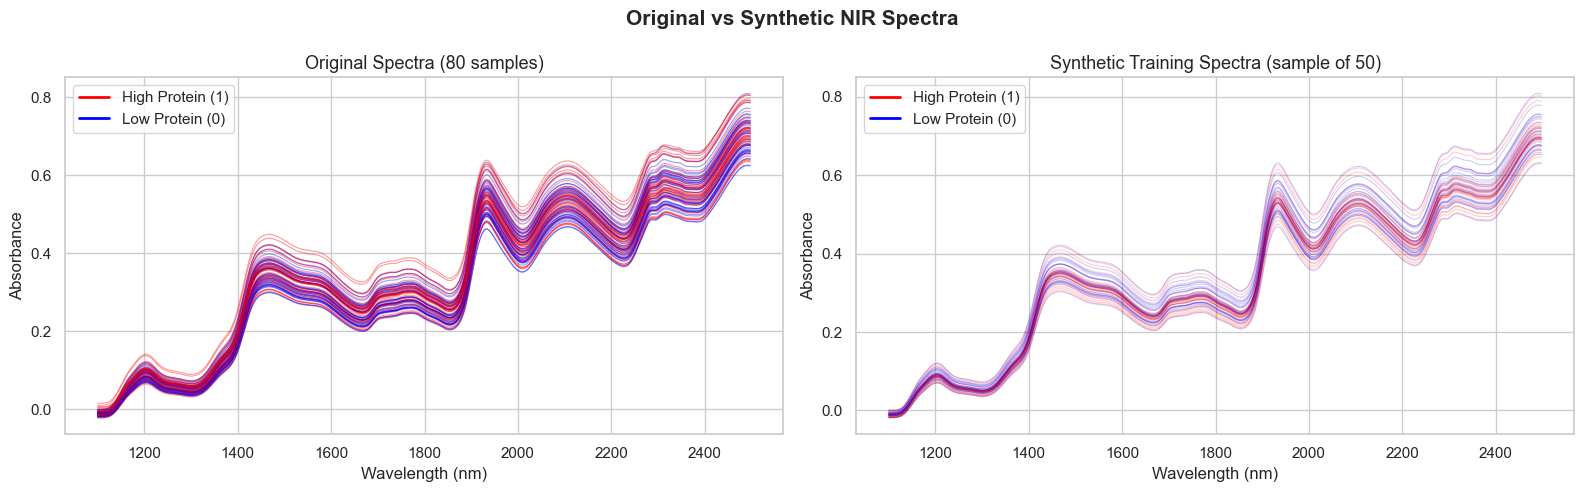

In [26]:
wavelengths = np.linspace(1100, 2498, 700)

# Sample 50 synthetic spectra for the right panel (to keep the plot readable)
np.random.seed(42)
sample_idx = np.random.choice(n_synthetic, size=50, replace=False)
X_sample   = X_synthetic[sample_idx]
y_sample   = y_synthetic[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Original vs Synthetic NIR Spectra', fontsize=15, fontweight='bold')

# --- Left: all 80 original spectra ---
for i in range(len(X)):
    color = 'red' if y[i] == 1 else 'blue'
    axes[0].plot(wavelengths, X[i], color=color, alpha=0.4, linewidth=0.8)

axes[0].set_xlabel('Wavelength (nm)', fontsize=12)
axes[0].set_ylabel('Absorbance', fontsize=12)
axes[0].set_title('Original Spectra (80 samples)', fontsize=13)

# Manual legend patches
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='red',  linewidth=2, label='High Protein (1)'),
    Line2D([0], [0], color='blue', linewidth=2, label='Low Protein (0)'),
]
axes[0].legend(handles=legend_handles, fontsize=11)

# --- Right: 50 sampled synthetic spectra ---
for i in range(len(X_sample)):
    color = 'red' if y_sample[i] == 1 else 'blue'
    axes[1].plot(wavelengths, X_sample[i], color=color, alpha=0.2, linewidth=0.8)

axes[1].set_xlabel('Wavelength (nm)', fontsize=12)
axes[1].set_ylabel('Absorbance', fontsize=12)
axes[1].set_title('Synthetic Training Spectra (sample of 50)', fontsize=13)
axes[1].legend(handles=legend_handles, fontsize=11)

plt.tight_layout()
plt.show()

## Section 6 — Visualize Class Distribution

This section compares the class compositions of the original test set and the synthetic training set.

Both sets should be approximately balanced (close to 50 % High Protein / 50 % Low Protein). If one class dominates the training set, the model will be biased toward predicting that class more often — a balanced synthetic set helps avoid this problem.

Since the linear interpolation mixes pairs of originals and rounds the interpolated label, the class balance in the synthetic set is inherited from the original class balance. If the originals are balanced, the synthetic set will also be approximately balanced.

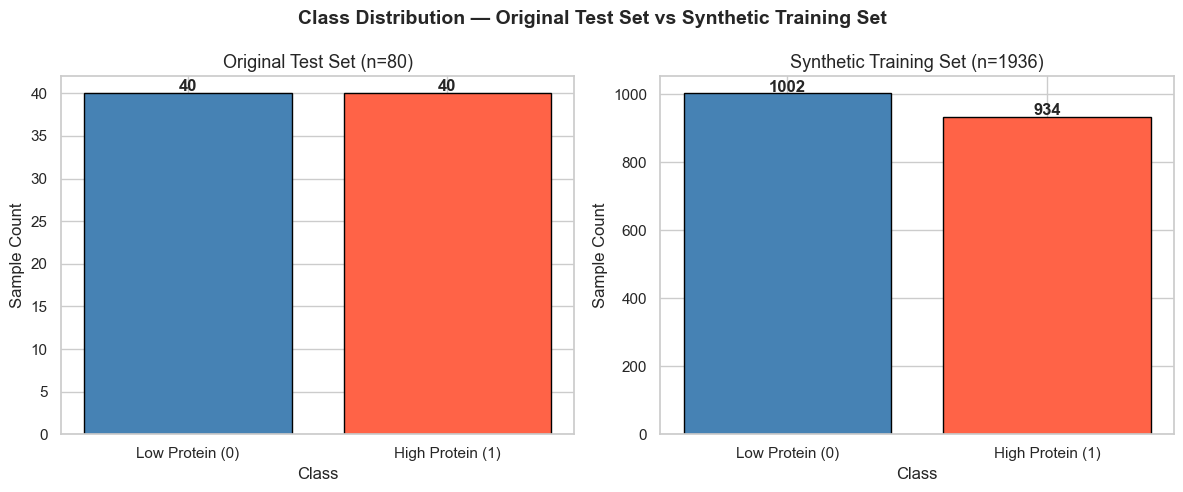

In [27]:
tick_labels = ['Low Protein (0)', 'High Protein (1)']

# Count class occurrences
test_classes,  test_counts  = np.unique(y_test_all,  return_counts=True)
train_classes, train_counts = np.unique(y_synthetic, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'Class Distribution — Original Test Set vs Synthetic Training Set',
    fontsize=14, fontweight='bold',
)

# --- Left: original test set ---
axes[0].bar(tick_labels, test_counts, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title(f'Original Test Set (n={len(y_test_all)})', fontsize=13)
axes[0].set_ylabel('Sample Count', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
for i, cnt in enumerate(test_counts):
    axes[0].text(i, cnt + 0.3, str(cnt), ha='center', fontsize=12, fontweight='bold')

# --- Right: synthetic training set ---
axes[1].bar(tick_labels, train_counts, color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title(f'Synthetic Training Set (n={n_synthetic})', fontsize=13)
axes[1].set_ylabel('Sample Count', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
for i, cnt in enumerate(train_counts):
    axes[1].text(i, cnt + 5, str(cnt), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Section 7 — Save All Output Files

This section saves the four NumPy arrays and one CSV file that will be used by all subsequent revised notebooks.

| File | Contents | Used for |
|---|---|---|
| `X_train_synthetic.npy` | 1936 synthetic spectra, shape (1936, 700) | Model training |
| `y_train_synthetic.npy` | Labels for synthetic set, shape (1936,) | Model training |
| `X_test_all.npy` | All 80 original spectra, shape (80, 700) | Final evaluation only |
| `y_test_all.npy` | All 80 original labels, shape (80,) | Final evaluation only |
| `combined_augmented_revised.csv` | Synthetic set as a table with wavelength columns | Documentation |

> **Important:** `X_test_all.npy` and `y_test_all.npy` must NOT be used during model training, hyperparameter tuning, or any form of model selection. They are to be opened only once — during final evaluation in the revised Notebook 07.
>
> `combined_augmented_revised.csv` is large (~10 MB). It is saved for thesis documentation purposes only and should be added to `.gitignore`.

In [28]:
out_dir = '../../data/processed/revised'
os.makedirs(out_dir, exist_ok=True)

# --- Save NumPy arrays ---
np.save(f'{out_dir}/X_train_synthetic.npy', X_synthetic)
print(f"Saved X_train_synthetic.npy   shape={X_synthetic.shape}")

np.save(f'{out_dir}/y_train_synthetic.npy', y_synthetic)
print(f"Saved y_train_synthetic.npy   shape={y_synthetic.shape}")

np.save(f'{out_dir}/X_test_all.npy', X_test_all)
print(f"Saved X_test_all.npy          shape={X_test_all.shape}")

np.save(f'{out_dir}/y_test_all.npy', y_test_all)
print(f"Saved y_test_all.npy          shape={y_test_all.shape}")

# --- Save CSV for documentation ---
wave_cols = [f'Wave_{i+1}' for i in range(X_synthetic.shape[1])]
df_synthetic = pd.DataFrame(X_synthetic, columns=wave_cols)
df_synthetic['Protein_Label'] = y_synthetic

csv_path = f'{out_dir}/combined_augmented_revised.csv'
df_synthetic.to_csv(csv_path, index=False)
print(f"Saved combined_augmented_revised.csv  shape={df_synthetic.shape}")

print("\nAll output files saved successfully to data/processed/revised/")

Saved X_train_synthetic.npy   shape=(1936, 700)
Saved y_train_synthetic.npy   shape=(1936,)
Saved X_test_all.npy          shape=(80, 700)
Saved y_test_all.npy          shape=(80,)
Saved combined_augmented_revised.csv  shape=(1936, 701)

All output files saved successfully to data/processed/revised/


## Section 8 — Summary

This notebook implemented a **revised data augmentation strategy** for the NIR maize protein classification pipeline.

---

### What Changed from the Original Approach

| Aspect | Original (`04_augmentation.ipynb`) | Revised (this notebook) |
|---|---|---|
| Train / test split | 80 % train / 20 % test (64 / 16) | No split — all 80 originals → test |
| Test set size | 16 samples | **80 samples** |
| Training data | 64 originals + augmented copies | **1936 synthetic samples only** |
| Original samples in training | Yes (64) | **No** |

---

### Augmentation Details

- **Method:** Linear interpolation (convex combination) between pairs of original spectra
- **Formula:** `x_new = α × X[i] + (1 − α) × X[j]`; `y_new = round(α × y[i] + (1 − α) × y[j])`
- **Alpha range:** Uniform(0.1, 0.9) — ensures synthetic samples are strictly between two originals
- **Synthetic samples generated:** 1936
- **Reference:** Li et al. (2025), SpecTran study

---

### Output Files (`data/processed/revised/`)

| File | Shape | Purpose |
|---|---|---|
| `X_train_synthetic.npy` | (1936, 700) | Training input |
| `y_train_synthetic.npy` | (1936,) | Training labels |
| `X_test_all.npy` | (80, 700) | Evaluation input (held out) |
| `y_test_all.npy` | (80,) | Evaluation labels (held out) |
| `combined_augmented_revised.csv` | (1936, 701) | Documentation only |

---

### Methodological Justification

Reserving all 80 original samples as the test set produces **5× more test samples** than the original 16-sample split. This reduces the per-error accuracy granularity from 6.25 % to 1.25 %, yielding evaluation metrics that are far more statistically reliable and less sensitive to individual prediction outcomes.

---

> **Next step — `notebooks/revised/05_plsda_svm_revised.ipynb`:** Trains PLS-DA and SVM models on `X_train_synthetic.npy` and evaluates them on all 80 original samples in `X_test_all.npy`.